https://d2l.ai/chapter_linear-classification/softmax-regression.html

## The Image CLassification Dataset

In [1]:
import time, torch, torchvision, os, sys
from torchvision import transforms
from d2l import torch as d2l

class FashionMNIST(d2l.DataModule):  #@save
    def __init__(self, batch_size=64, resize=(28, 28)): # have batch sizes as 64 photos and resize the images to 28x28 pixels
        super().__init__()
        self.save_hyperparameters()
        trans = transforms.Compose([transforms.Resize(resize),
                                    transforms.ToTensor()]) # transform the images to tensors and resize them to 28x28 pixels
        self.train = torchvision.datasets.FashionMNIST(
            root=self.root, train=True, transform=trans, download=True) # define a training set
        self.val = torchvision.datasets.FashionMNIST(
            root=self.root, train=False, transform=trans, download=True) # define a test set

In [5]:
data = FashionMNIST(batch_size=64)

In [4]:
@d2l.add_to_class(FashionMNIST) #@save
def text_labels(self, indices):
    labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
              'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [labels[i] for i in indices]


In [ ]:
@d2l.add_to_class(FashionMNIST) #@save
def get_dataloader(self, train): # gets the correct data loader and gets the batches
    data = self.train if train else self.val
    return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train, num_workers=self.num_workers)

In [7]:
X,y = next(iter(data.train_dataloader()))
print(X.shape, X.dtype, y.shape, y.dtype)

torch.Size([64, 1, 28, 28]) torch.float32 torch.Size([64]) torch.int64


In [ ]:
tic = time.time()
for X, y in data.train_dataloader():
    continue
f'{time.time() - tic:.2f} sec' # i/o of reading the data

'1.72 sec'

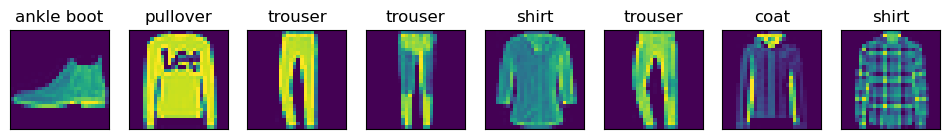

In [16]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5): #@save
    raise NotImplementedError

@d2l.add_to_class(FashionMNIST)  #@save
def visualize(self, batch, nrows=1, ncols=8, labels=[]): # visualize the images in the batch
    X, y = batch
    if not labels:
        labels = self.text_labels(y)
    d2l.show_images(X.squeeze(1), nrows, ncols, titles=labels)
batch = next(iter(data.val_dataloader()))
data.visualize(batch)

## Base Classification Model

In [19]:
import torch 
from d2l import torch as d2l

class Classifier(d2l.Module): #@save
    def validation_step(self, batch):
        Y_hat = self(*batch[:-1]) # unpack the batch 
        self.plot('loss', self.loss(Y_hat, batch[-1]), train=False) # plot the test loss
        self.plot('acc', self.accuracy(Y_hat, batch[-1]), train=False) # plot the test accuracy
        

@d2l.add_to_class(d2l.Module)  #@save
def configure_optimizers(self): # configure the optimizer
    return torch.optim.SGD(self.parameters(), lr=self.lr) # use stochastic gradient descent 

@d2l.add_to_class(d2l.Module)  #@save
def accuracy(self, Y_hat, Y, averaged=True):
    Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1])) # reshape the predictions to be 2D
    preds = Y_hat.argmax(axis=1).type(Y.dtype) # get the predicted class labels
    compare = (preds == Y.reshape(-1)).type(torch.float32) # compare the predicted labels to the true labels
    return compare.mean() if averaged else compare # return the mean accuracy if averaged is True, otherwise return the individual accuracies

## Softmax Implementation of Softmax Regression

In [20]:
import torch, numpy, os, sys
from d2l import torch as d2l

X =torch.tensor([[1.0, 2.0, 3.0],[4.0, 5.0, 6.0]])
X.sum(0, keepdim=True), X.sum(1, keepdim=True) # sum along the columns and rows

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

In [22]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True) # get the total sum of the exponentials for each row
    return X_exp / partition  # divide each exponential by the total sum to get the softmax probabilities for each row (sample)

In [24]:
X = torch.rand((2,5))
X_prob = softmax(X)
X_prob, X_prob.sum(1) # check that the softmax probabilities sum to 1 for each row (sample)

(tensor([[0.2393, 0.2233, 0.2121, 0.1382, 0.1872],
         [0.3061, 0.1288, 0.1287, 0.2930, 0.1434]]),
 tensor([1.0000, 1.0000]))

In [26]:
class SoftmaxRegressionScratch(d2l.Classifier): #@save
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs), requires_grad=True) # initialize the weights
        self.b = torch.zeros(num_outputs, requires_grad=True) # initialize the bias
        
    def parameters(self):
        return[self.W, self.b]

In [27]:
@d2l.add_to_class(SoftmaxRegressionScratch)
def forward(self, X):
    X = X.reshape((-1, self.W.shape[0])) # flatten the input images because the weights are 2D
    return softmax(torch.matmul(X, self.W) + self.b) # compute the softmax probabilities for each class

In [30]:
y = torch.tensor([0, 2]) # true labels for the two samples 
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]]) # predicted probabilities for each class for the two samples
y_hat[[0, 1], y] 

tensor([0.1000, 0.5000])

In [31]:
def cross_entropy(y_hat, y):
    val = -torch.log(y_hat[list(range(len(y_hat))), y]).mean() # compute the negative log likelihood of the predicted probabilities for the true labels and take the mean
    return val

@d2l.add_to_class(SoftmaxRegressionScratch)
def loss(self, y_hat, y):
    return cross_entropy(y_hat, y)

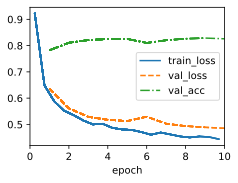

In [33]:
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegressionScratch(num_inputs=784, num_outputs=10, lr=0.1)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

In [34]:
X,y = next(iter(data.train_dataloader()))
preds = model(X).argmax(axis=1)
preds.shape

torch.Size([256])

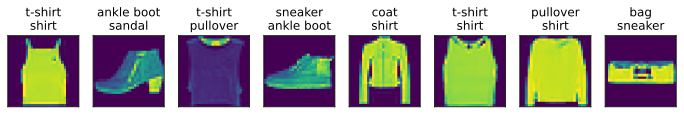

In [35]:
wrong = preds.type(y.dtype) != y # get the sample indeces that were incorrectly classified
X, y, preds = X[wrong], y[wrong], preds[wrong] # get the incorrectly classified samples
labels = [a+'\n'+b for a, b in zip(
    data.text_labels(y), data.text_labels(preds))]
data.visualize([X, y], labels=labels)